In [ ]:
# Install hypertools (dev-2.0-refactor preview) -- run this first on Colab.
# On release this becomes: %pip install hypertools
%pip install -q "hypertools[interactive] @ git+https://github.com/ContextLab/hypertools.git@dev-2.0-refactor"

# Normalization

The `normalize` is a helper function to z-score your data. This is useful if your features (columns) are scaled differently within or across datasets. By default, hypertools normalizes *across* the columns of all datasets passed, but also affords the option to normalize columns *within* individual lists. Alternatively, you can also normalize each row. The function returns an array or list of arrays where the columns or rows are z-scored (output type same as input type).

## Import packages

In [1]:
import hypertools as hyp
import numpy as np

%matplotlib inline

## Generate synthetic data

First, we generate two sets of synthetic data. We pull points randomly from a multivariate normal distribution for each set, so the sets will exhibit unique statistical properties.

In [2]:
x1 = np.random.randn(10,10)
x2 = np.random.randn(10,10)

c1 = np.dot(x1, x1.T)
c2 = np.dot(x2, x2.T)

m1 = np.zeros([1,10])
m2 = 10 + m1

data1 = np.random.multivariate_normal(m1[0], c1, 100)
data2 = np.random.multivariate_normal(m2[0], c2, 100)

data = [data1, data2]

## Visualize the data

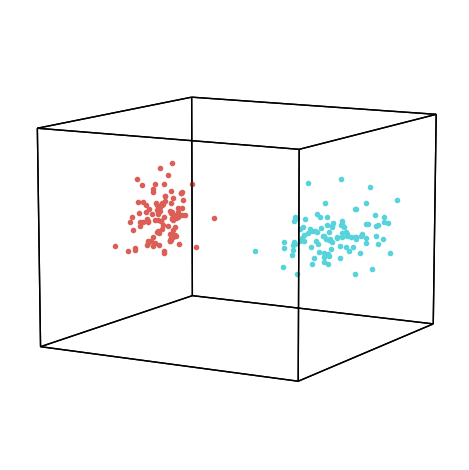

In [3]:
fig = hyp.plot(data, '.')

## Normalizing (Specified Cols or Rows)

Or, to specify a different normalization, pass one of the following arguments as a string, as shown in the examples below.

+ 'across' - columns z-scored across passed lists (default)
+ 'within' - columns z-scored within passed lists
+ 'row' - rows z-scored 

### Normalizing 'across'

When you normalize 'across', all of the data is stacked/combined, and the normalization is done on the columns of the full dataset. Then the data is split back into separate elements.

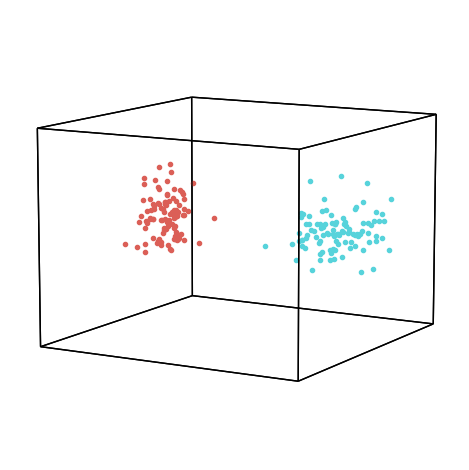

In [4]:
norm = hyp.normalize(data, normalize = 'across')
fig = hyp.plot(norm, '.')

### Normalizing 'within'

When you normalize 'within', normalization is done on the columns of each element of the data, separately. 

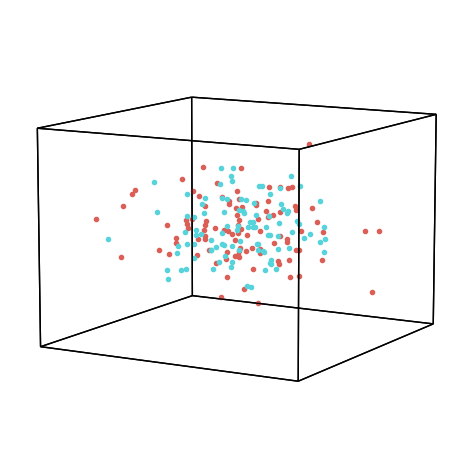

In [5]:
norm = hyp.normalize(data, normalize = 'within')
fig = hyp.plot(norm, '.')

### Normalizing by 'row'

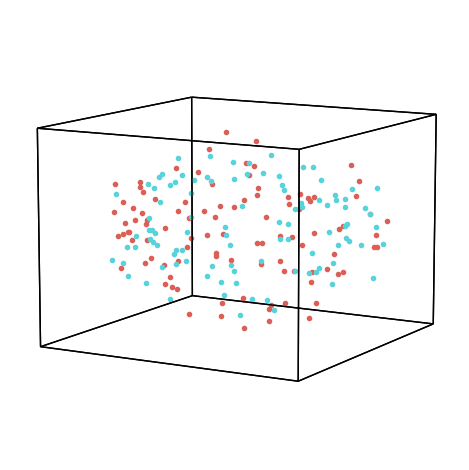

In [6]:
norm = hyp.normalize(data, normalize = 'row')
fig = hyp.plot(norm, '.')